### 加载数据

In [35]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skfolio import Population,MultiPeriodPortfolio
from skfolio.datasets import load_sp500_dataset
from skfolio.preprocessing import prices_to_returns
from ml4t.data.providers.qmt_provider import QmtProvider
from sklearn import set_config
from log_result import init_logger, log_result, log_print
set_config(transform_output="pandas")
init_logger("WF_CPCV_PS_252")      # 只调用一次, 绑定文件名
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False   # 关键: 负号才不会变方块

[log] 已绑定: D:\machine-learning-for-trading\case_studies\lazy_trading\logs\WF_CPCV_PS_252.log


In [36]:
# 加载数据
prices = pl.read_parquet("hs_funds_prices.parquet").to_pandas()
prices = prices.set_index('timestamp')
prices = prices.ffill()
prices = prices[prices.index.year > 2015]
all_symbols = prices.columns
print(f"资产池: {len(all_symbols)} 只 | {len(prices)} 天 | {prices.index[0].date()} ~ {prices.index[-1].date()}")

# 市场基准（从资产池中取出）
bench_symbol = "510300.SH"
bench = prices[bench_symbol]
prices = prices.drop(columns=[bench_symbol])

# 双口径收益率: X=绝对收益, X_net=超额收益(减基准), 筛选与训练统一用X_net
X = prices_to_returns(prices, drop_inceptions_nan=False)
bench_ret = prices_to_returns(bench.to_frame("bench"), drop_inceptions_nan=False)["bench"]
X_net = X.sub(bench_ret, axis=0)

# Inf 检查（两口径分别报告）
for label, df in [("X", X), ("X_net", X_net)]:
    inf = df.columns[np.isinf(df).any(axis=0)]
    print(f"{label} Inf列 {len(inf)}" + (f" -> {inf.tolist()}" if len(inf) else ""))

# 异常收益检查: 以超额口径判定, 同步剔除, 保证两口径列集一致
bad = X_net.columns[(X_net.abs() > 0.25).any()]
X = X.drop(columns=bad)
X_net = X_net.drop(columns=bad)
msg = f"异常剔除(±25%): {len(bad)} 列 -> {bad.tolist()}" if len(bad) else "异常剔除(±25%): 0 列"
print(msg)
print(f"清洗后: {X.shape[0]} 天 x {X.shape[1]} 资产 | 列集一致: {list(X.columns) == list(X_net.columns)}")

资产池: 2116 只 | 2579 天 | 2016-01-04 ~ 2026-08-14
X Inf列 0
X_net Inf列 0
异常剔除(±25%): 3 列 -> ['161811.SZ', '510030.SH', '511580.SH']
清洗后: 2578 天 x 2112 资产 | 列集一致: True


### 参数搜索
- Walkforward:
    - CombinatorialPurgedCV

In [37]:
from wf_cpcv_search import load_nested_config
from cpcv_search_base import build_pipeline_src
from walkforward_parameter_search import compute_grid_size
from wf_cpcv_search import nested_adaptive_search, adaptive_multi_paths, build_test_parts, summarize_fold_params,summarize_top_k_params
from cpcv_analysis import discrete_lhs_safe, diagnose_oos_lhs, report_ann_distribution, turnover_series
from cpcv_analysis import plot_oos_vs_bench,excess_vs_bench
from wf_cpcv_robustness import (perturbation_mc, sensitivity_curves, sensitivity_heatmap, topk_paths_eval,)
from wf_cpcv_ablation import ablate

In [38]:
log_print("mean(Annualized Sharpe Ratio) - mean(MAXDD)", section='Ojective', echo=False)
log_print(build_pipeline_src(), section="Model Pipeline", echo=False)

In [ ]:
search_space = {'nondomin__min_n_assets': {'low': 5, 'high': 25, 'step': 5},
 'nondomin__threshold': {'low': -0.5, 'high': -0.3, 'step': 0.1},
 'correlate__threshold': {'low': 0.1, 'high': 0.6, 'step': 0.1},
 'extremes__k': {'low': 0.1, 'high': 0.5, 'step': 0.1},
 'nondomin__fitness_measures': [
    "mean-variance-kurt",
    "mean-variance-maxdd-kurt",
    "mean-variance-avgdd-kurt",
    "mean-semideviation-avgdd",
    "mean-mad-maxdd-kurt",
    "mean-mad-avgdd-kurt",
    "mean-mad-maxdd-cvar-kurt",
    "mean-mad-maxdd-cvar-sharpe",
    "mean-mad-avgdd-cvar-kurt",
    "mean-mad-avgdd-cvar-sharpe",
    ],
 'train_size': {'low': 252, 'high': 756, 'step': 126}}  # inner train size
log_print(search_space, section='Parameter Space', echo=False)
compute_grid_size(search_space)

22500

In [40]:
search_params = {'test_size': 252,
  'train_size': 756+252,
  'n_test_folds': 2,
  'n_jobs': 4,
  'cv_n_jobs': 12,
  'n_trials': 1000,
  'patience': 20,
  'sampler': 'tpe',
  'min_delta': 0.0001,
  'outer_purged_size': 1,
  'outer_reduce_test': True,
  'seed': 42,
  'verbose': True}
log_print(search_params, section="Search Parameter", echo=False)

In [41]:
fold_results = nested_adaptive_search(X,space=search_space, **search_params)

  0%|          | 0/1000 [00:00<?, ?it/s]

Fold 0: mean score=1.0462 | test_ann=0.1928 | test_days=252


  0%|          | 0/1000 [00:00<?, ?it/s]

Fold 1: mean score=1.8615 | test_ann=0.0203 | test_days=252


  0%|          | 0/1000 [00:00<?, ?it/s]

...

Fold 4: mean score=0.5436 | test_ann=0.0876 | test_days=252


  0%|          | 0/1000 [00:00<?, ?it/s]

Fold 5: mean score=0.6945 | test_ann=0.1823 | test_days=252


  0%|          | 0/1000 [00:00<?, ?it/s]

Fold 6: mean score=1.5496 | test_ann=-0.0737 | test_days=57


### Step 1 | IS 审计：每折 DSR + Top-K 候选
- dsr = 该折最优分数超过"纯运气挑最优"基准的经验概率（H0 噪声 MC deflate，N = 参数去重后的真实试验数）。 margin = sr_obs − E[max_N]，max_p95 为运气基准 95% 分位。
- gap2top1（summarize_top_k_params 的列）= IS 侧 top1 与 top2 的分数落差： 落差小 → 参数处在平台（好信号）；落差大 → top1 可能是运气孤峰（坏信号）。

In [42]:
log_print(summarize_fold_params(fold_results).to_string(),section='Best Parameter', echo=True)

   fold   score     dsr  sr_obs  margin  train ASR  test ASR  nondomin__min_n_assets  nondomin__threshold  correlate__threshold  extremes__k  train_size                     fitness  n_trials
0     0  1.0462  0.9993  1.0462  0.5724     1.7864    1.6473                      15                 -0.5                   0.5          0.3         252    mean-mad-maxdd-cvar-kurt        28
1     1  1.8615  0.9956  1.8615  0.7739     2.5675    0.3578                      15                 -0.5                   0.5          0.4         252         mean-mad-maxdd-kurt        44
2     2  1.1113  0.9861  1.1113  0.4170     1.7571    0.1284                      20                 -0.3                   0.5          0.5         504    mean-mad-avgdd-cvar-kurt        33
3     3  0.9089  0.8983  0.9089  0.1917     1.5096   -0.0604                      20                 -0.3                   0.4          0.5         756  mean-mad-maxdd-cvar-sharpe        52
4     4  0.5436  0.1129  0.5436 -0.2340     0

In [43]:
topk = summarize_top_k_params(fold_results, k=5)         # 行 = (fold, rank)
print(topk[topk["rank"] <= 3][['fold','rank','score','gap2top1']])                    # 每折 top1/top2 候选 + gap2top1

    fold  rank   score  gap2top1
0      0     1  1.0462    0.0000
1      0     2  0.8962    0.1500
2      0     3  0.8143    0.2319
5      1     1  1.8615    0.0000
6      1     2  1.8475    0.0140
7      1     3  1.8475    0.0140
10     2     1  1.1113    0.0000
11     2     2  1.0910    0.0203
12     2     3  1.0910    0.0203
15     3     1  0.9089    0.0000
16     3     2  0.8335    0.0754
17     3     3  0.8220    0.0869
20     4     1  0.5436    0.0000
21     4     2  0.5426    0.0010
22     4     3  0.4934    0.0502
25     5     1  0.6945    0.0000
26     5     2  0.6568    0.0377
27     5     3  0.6402    0.0543
30     6     1  1.5496    0.0000
31     6     2  1.4950    0.0546
32     6     3  1.4950    0.0546


### Step 2｜过拟合判据：DSR 低 + OOS 衰减
- 判据：WFE > 0.5 为稳健泛化（多数折满足）。
- "DSR 低 + OOS 显著下降" = 内层选择偏差校正后无真实优势 + 样本外掉队 → 该折结论不可信，

In [44]:
df = summarize_fold_params(fold_results).copy()
df["WFE"] = df["test ASR"] / df["train ASR"]      # 每折 IS→OOS 衰减比
df["flag"] = (df["dsr"] < 0.5) & (df["WFE"] < 0.5)   # 双低 = 过拟合嫌疑折
print(df[["fold", "dsr", "train ASR", "test ASR", "WFE", "flag"]])

   fold     dsr  train ASR  test ASR       WFE   flag
0     0  0.9993     1.7864    1.6473  0.922134  False
1     1  0.9956     2.5675    0.3578  0.139357  False
2     2  0.9861     1.7571    0.1284  0.073075  False
3     3  0.8983     1.5096   -0.0604 -0.040011  False
4     4  0.1129     0.7499    0.5313  0.708494  False
5     5  0.9380     1.1265    1.5804  1.402929  False
6     6  0.9999     1.9131   -0.7933 -0.414667  False


### Step 3｜Top-K 候选 OOS 多路径压测
- 窗口自动从 folds 推导（折位 1:1）；如需 notebook 原压测口径（如 `n_test_folds=4`），
  以显式键传入：`topk_paths_eval(X, folds, paths_kwargs={"n_test_folds": 4})`。
- 价值在**参数高原的 OOS 侧印证**：gap2top1 小的候选若 OOS 同样接近，说明生产参数处在稳定平台。

In [45]:
eval_ = topk_paths_eval(X, fold_results, k=5)            # 每折 top1~5 全部进 CPCV 多路径压测

Fold 5: paths=7 | window=1008 | inner_folds=8 | test_days=252
Fold 5 rank4: score=0.6361 | 多路径压测完成
Fold 5: paths=4 | window=630 | inner_folds=5 | test_days=252
Fold 5 rank5: score=0.6127 | 多路径压测完成
Fold 6 rank1: score=1.5496 | 多路径压测完成
Fold 6 rank2: score=1.4950 | 多路径压测完成
Fold 6 rank3: score=1.4950 | 多路径压测完成
Fold 6 rank4: score=1.4570 | 多路径压测完成
Fold 6 rank5: score=1.4527 | 多路径压测完成


In [46]:

paths = eval_["paths"]                            # MultiIndex (fold, rank, path)
audit = eval_["audit"]                            # IS 侧审计，与 paths 按 (fold, rank) 对齐
sharpe = paths["annualized_sharpe_ratio"].groupby("rank").mean()
print(sharpe)              # rank 均值对比（不选参，只看高原）

rank
1    0.692564
2    0.322172
3    0.614368
4    0.789178
5    0.324874
Name: annualized_sharpe_ratio, dtype: float64


### Step 4｜单参数敏感性曲线
- 每折只动目标参数、其余保持生产值（fitness 固定 top1）；`frac=0` 档即生产值本身（锚点）。
- 默认覆盖**全部数值参数含 `train_size`**（它是搜索维度之一，扰动后评估即用扰动后的拟合窗口长度）。
- 读图：参数高原 = ±30% 内绩效平缓；孤峰 = 仅生产值附近突出（与 IS 侧 gap2top1 互证）。
- 只评估单折 OOS → 无 CPCV 展开，成本低，可全参数全档位跑。

Fold 0: 单参网格完成 (5 参数 × 6 档)
Fold 1: 单参网格完成 (5 参数 × 6 档)
Fold 2: 单参网格完成 (5 参数 × 6 档)
Fold 3: 单参网格完成 (5 参数 × 6 档)
Fold 4: 单参网格完成 (5 参数 × 6 档)
Fold 5: 单参网格完成 (5 参数 × 6 档)
Fold 6: 单参网格完成 (5 参数 × 6 档)


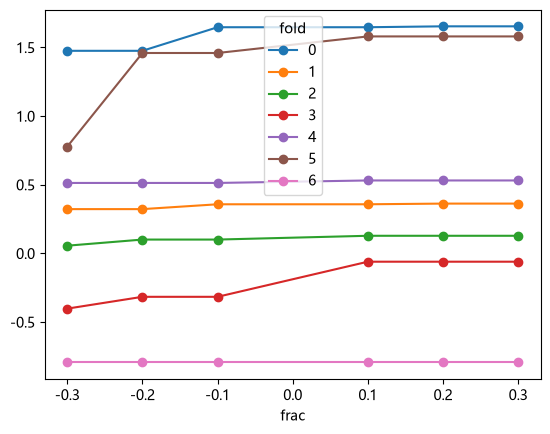

In [47]:
curves = sensitivity_curves(X, fold_results)             # 默认 ±10/20/30% 六档 × 全部数值参数
c = curves[curves["param"] == "extremes__k"]
ax = c.pivot_table(index="frac", columns="fold",
                   values="annualized_sharpe_ratio").plot(marker="o")

### Step 5｜双参数联合热力图（checklist 4.2）

- 返回 `{fold: DataFrame(index=frac_a, columns=frac_b), "mean": 跨折逐格平均}`。
- 读图：各档平缓 → 联合高原（稳健）；仅 (0,0) 突出 → 联合孤峰（脆弱）；
  对角陡峭 → 两参数互补/冲突（交互项存在）。

Fold 0: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 1: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 2: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 3: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 4: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 5: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 6: extremes__k×correlate__threshold 热力图 (5×5) 完成


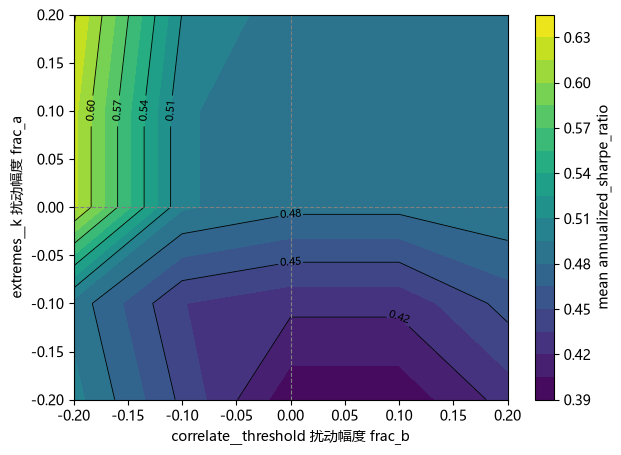

In [48]:
import numpy as np
import matplotlib.pyplot as plt

grids = sensitivity_heatmap(X, fold_results, param_a="extremes__k",
                            param_b="correlate__threshold")
mean = grids["mean"]                          # 行=frac_a, 列=frac_b, 值=跨折平均ASR
Xg, Yg = np.meshgrid(mean.columns, mean.index)   # x=frac_b, y=frac_a，与 values[i,j] 对齐
fig, ax = plt.subplots(figsize=(7, 5))
cf = ax.contourf(Xg, Yg, mean.values, levels=15, cmap="viridis")   # 彩色填充
cs = ax.contour(Xg, Yg, mean.values, levels=8, colors="k", linewidths=0.6)  # 等值线
ax.clabel(cs, inline=True, fontsize=8)        # 标数值
ax.axhline(0, color="gray", lw=0.8, ls="--")  # 生产值锚点十字线（0,0 = 未扰动）
ax.axvline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("correlate__threshold 扰动幅度 frac_b")
ax.set_ylabel("extremes__k 扰动幅度 frac_a")
fig.colorbar(cf, label="mean annualized_sharpe_ratio")

### Step 6｜消融实验

- 臂：`full`（基准）/ `no_extremes` / `no_nondomin` / `no_correlate` / `no_extremes_correlate`。
- 每臂 = 固定每折最优参数 × 剔除对应管线步骤 × CPCV 多路径压测（同窗同口径对比）。
- 判读：全臂样本路径数一致（每折 = `n_test_folds` 组合路径），绩效差距即模块边际贡献；
  某模块剔除后绩效**不降反升** → 该模块负贡献，考虑剔除后重搜（会作废旧 OOS）。

In [49]:
frames, summary = ablate(X, fold_results)                # arms=None = 全部 5 臂
summary[["说明", "annualized_mean_mean", "annualized_sharpe_ratio_mean",
               "max_drawdown_mean", "样本数"]]

Fold 0: paths=3 | window=504 | inner_folds=4 | test_days=252
Fold 1: paths=3 | window=504 | inner_folds=4 | test_days=252
Fold 2: paths=5 | window=756 | inner_folds=6 | test_days=252
Fold 3: paths=7 | window=1008 | inner_folds=8 | test_days=252
Fold 4: paths=4 | window=630 | inner_folds=5 | test_days=252
Fold 5: paths=4 | window=630 | inner_folds=5 | test_days=252
Fold 0: paths=3 | window=504 | inner_folds=4 | test_days=252
Fold 1: paths=3 | window=504 | inner_folds=4 | test_days=252
Fold 2: paths=5 | window=756 | inner_folds=6 | test_days=252
Fold 3: paths=7 | window=1008 | inner_folds=8 | test_days=252
Fold 4: paths=4 | window=630 | inner_folds=5 | test_days=252
Fold 5: paths=4 | window=630 | inner_folds=5 | test_days=252
Fold 0: paths=3 | window=504 | inner_folds=4 | test_days=252
Fold 1: paths=3 | window=504 | inner_folds=4 | test_days=252
Fold 2: paths=5 | window=756 | inner_folds=6 | test_days=252
Fold 3: paths=7 | window=1008 | inner_folds=8 | test_days=252
Fold 4: paths=4 | win

,说明,annualized_mean_mean,annualized_sharpe_ratio_mean,max_drawdown_mean,样本数
臂,,,,,
full,全管线（基准）,0.068620,0.692564,0.089182,26
no_extremes,无峰度预筛（剔除 extremes 步骤）,0.068083,0.879292,0.057295,26
no_nondomin,无非支配筛选（剔除 nondomin 步骤）,0.047965,0.487717,0.110933,26
no_correlate,无去相关（剔除 correlate 步骤）,0.088495,0.568317,0.123259,26
no_extremes_correlate,剔除 extremes + correlate,0.091175,0.738598,0.089834,26


### Step 7｜参数扰动蒙特卡洛 + 判定

In [50]:
out = perturbation_mc(X, fold_results)                   # R=None → ceil(500 / 折数)，总样本 ≥ 500

Fold 0: R=72 | fitness池=['mean-mad-maxdd-cvar-kurt', 'mean-variance-avgdd-kurt', 'mean-mad-avgdd-cvar-sharpe'] | 扰动脉冲完成（72 组 × 普通OOS单测）
Fold 1: R=72 | fitness池=['mean-mad-maxdd-kurt', 'mean-mad-maxdd-cvar-kurt', 'mean-mad-maxdd-cvar-sharpe'] | 扰动脉冲完成（72 组 × 普通OOS单测）
Fold 2: R=72 | fitness池=['mean-mad-avgdd-cvar-kurt', 'mean-mad-maxdd-kurt', 'mean-mad-avgdd-kurt'] | 扰动脉冲完成（72 组 × 普通OOS单测）
Fold 3: R=72 | fitness池=['mean-mad-maxdd-cvar-sharpe', 'mean-variance-maxdd-kurt', 'mean-mad-avgdd-cvar-kurt'] | 扰动脉冲完成（72 组 × 普通OOS单测）
Fold 4: R=72 | fitness池=['mean-mad-maxdd-kurt', 'mean-mad-avgdd-cvar-kurt', 'mean-mad-maxdd-cvar-sharpe'] | 扰动脉冲完成（72 组 × 普通OOS单测）
Fold 5: R=72 | fitness池=['mean-mad-maxdd-cvar-kurt', 'mean-variance-maxdd-kurt', 'mean-mad-avgdd-cvar-kurt'] | 扰动脉冲完成（72 组 × 普通OOS单测）
Fold 6: R=72 | fitness池=['mean-mad-avgdd-cvar-sharpe', 'mean-mad-maxdd-cvar-kurt', 'mean-mad-avgdd-kurt'] | 扰动脉冲完成（72 组 × 普通OOS单测）


In [51]:
out['verdict']

,指标,样本数,prob>0,median,p95,通过
0,annualized_mean,504,0.861111,0.054119,0.205714,True
1,annualized_sharpe_ratio,504,0.861111,0.531294,2.020720,True


In [52]:
out['fold_summary']

,n,annualized_mean_mean,annualized_mean_median,annualized_mean_p5,annualized_mean_p95,annualized_sharpe_ratio_mean,annualized_sharpe_ratio_median,annualized_sharpe_ratio_p5,annualized_sharpe_ratio_p95,max_drawdown_mean,...,max_drawdown_p95,skew_mean,skew_median,skew_p5,skew_p95,kurtosis_mean,kurtosis_median,kurtosis_p5,kurtosis_p95,pos_prob
fold,,,,,,,,,,,,,,,,,,,,,
0,72,0.180281,0.192772,0.110645,0.230036,1.504212,1.530862,1.210455,1.769712,0.094565,...,0.122525,-0.438121,-0.498988,-0.614186,-0.126883,4.483657,4.479483,4.177591,4.900311,1.000000
1,72,0.020240,0.019460,0.004642,0.042997,0.320547,0.322545,0.063789,0.590357,0.088883,...,0.124066,-0.481673,-0.525983,-0.675884,-0.243088,4.441271,4.653315,3.735413,4.914916,0.958333
2,72,0.021115,0.016456,0.009477,0.045342,0.238962,0.196384,0.100831,0.442304,0.078132,...,0.088244,-0.392353,-0.425948,-0.485950,-0.285298,5.723969,5.586714,5.151435,6.351344,1.000000
3,72,0.066613,0.093903,-0.007761,0.109053,1.138028,1.759132,-0.100968,1.824708,0.055975,...,0.112931,-0.007009,0.006679,-0.101108,0.108719,3.072044,3.020275,2.780117,3.639266,0.875000
4,72,0.077755,0.086994,-0.015369,0.194510,0.604837,0.593313,-0.170670,1.342810,0.105848,...,0.159960,-1.296682,-1.318446,-1.870795,-0.334359,14.715529,17.134686,9.565550,18.402469,0.944444
5,72,0.145712,0.181155,0.004243,0.246829,1.493245,1.580386,0.095673,2.432225,0.063721,...,0.082813,-0.074618,-0.170390,-0.494166,0.579767,6.411845,6.029430,3.755518,9.710749,0.958333
6,72,-0.023220,-0.073733,-0.138989,0.156401,-0.045610,-0.560560,-1.193009,2.020720,0.065199,...,0.206853,-0.050420,-0.029127,-0.278006,0.127804,2.701432,2.515769,2.202328,3.785595,0.291667


In [53]:
oos_pop = Population([fold['test'] for fold in fold_results])
oos_pop.plot_cumulative_returns()

In [54]:
oos_mpt = MultiPeriodPortfolio([fold['test'] for fold in fold_results],compounded=True)
oos_mpt.plot_cumulative_returns()

#### 路径采样

In [27]:
fold_paths = adaptive_multi_paths(X, fold_results, 
                                 test_size=search_params['test_size'], 
                                 train_size=search_params['train_size'],
                                 n_test_folds=search_params['n_test_folds'], n_jobs=8)

Fold 0: paths=84 | window=630 | inner_folds=10 | test_days=252
Fold 1: paths=35 | window=504 | inner_folds=8 | test_days=252
Fold 2: paths=165 | window=756 | inner_folds=12 | test_days=252
Fold 3: paths=455 | window=1008 | inner_folds=16 | test_days=252
Fold 4: paths=165 | window=756 | inner_folds=12 | test_days=252
Fold 5: paths=84 | window=630 | inner_folds=10 | test_days=252


In [28]:
oos_blocks = build_test_parts(fold_paths, n_test_folds=search_params['n_test_folds'])
oos_paths = discrete_lhs_safe(oos_blocks, n_samples=1000, seed=42)
oos_mpts = Population([MultiPeriodPortfolio(path ,compounded=False) for path in oos_paths])

In [ ]:
oos_mpts.plot_cumulative_returns()

In [29]:
log_print(oos_mpt.summary(),section='OSS Summary',echo=False)

### OOS诊断：
- Annualized Mean 分布
- PSR诊断
- 基准联动
- 换手频率

LHS多路径分布(1000条): 均值 0.0589 | 中位 0.0590 | 5% 0.0272 | 95% 0.0903
WF真实路径: 0.0475 | 分布中 -0.58σ | 分位 28.2%


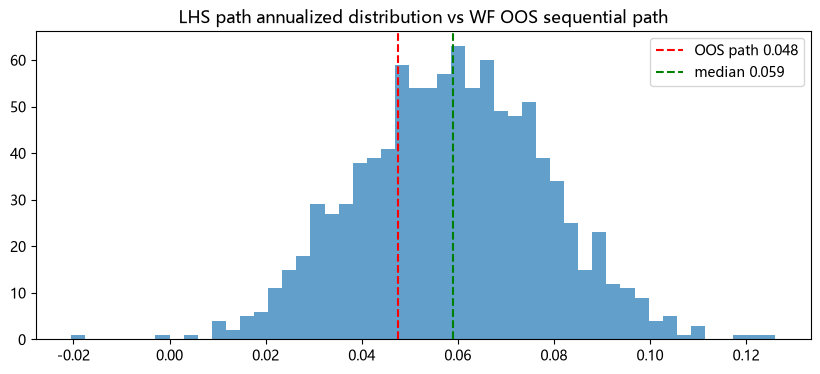

In [30]:
# 年化分布
path_anns = np.array([oos_mpt.annualized_mean for oos_mpt in oos_mpts])

oos_ann = oos_mpt.annualized_mean

report_ann_distribution(path_anns, oos_ann)

In [31]:
diagnose_result = diagnose_oos_lhs(lhs_paths=oos_paths)
del diagnose_result['mc_sharpes']
del diagnose_result['mc_mdds']
del diagnose_result['mc_psrs']
log_print(diagnose_result, section='OOS PSR Diagnose',echo=False)

[Info] 1000 LHS paths | OOS 1512 days

          纯 OOS 策略诊断报告 (LHS)
  ✅ P(SR<=0)              : 2.00%
  ✅ Sharpe 90% CI         : [0.079, 0.758]
  ✅ MDD median / worst-5%  : 15.50% / 21.69%
------------------------------------------------------------
  ⚠️ SR_obs (median)       : 0.4267
  ⚠️ PSR(0) median / 5%    : 100.00% / 99.86%


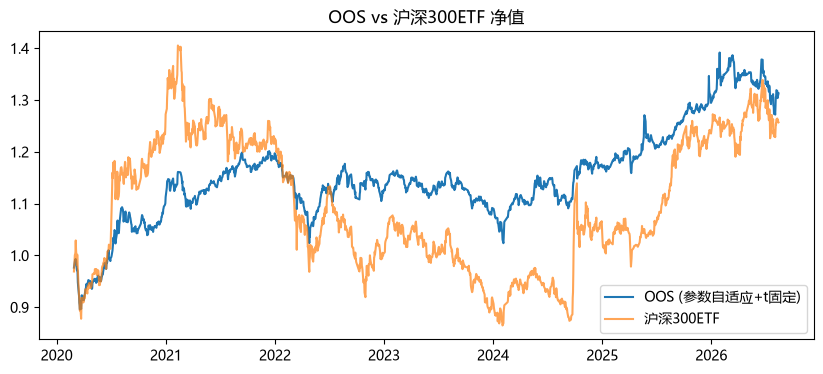

In [32]:
plot_oos_vs_bench(oos_mpt, bench_ret)

In [33]:

df_ex = excess_vs_bench(oos_mpts, bench_ret)
log_result(df_ex.describe(percentiles=[0.05, 0.5, 0.95]).loc[["5%", "50%", "95%", "mean"]].round(4),
           section="OOS vs 沪深300 相对收益分布")

      ann_excess  arith_excess      IR  winrate
5%       -0.0183       -0.0317 -0.2340   0.5079
50%       0.0121        0.0001  0.0008   0.5205
95%       0.0421        0.0314  0.2392   0.5344
mean      0.0120       -0.0000  0.0003   0.5209
